In [1]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.patches as mpatches
import pandas as pd

from xseas import SeasonDetect, X_labels


import matplotlib as mpl
from pathlib import Path

# Imposta stile globale
mpl.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [2]:
import yaml

with open('paths.local.yaml', 'r') as file:
    paths = yaml.safe_load(file)

FIGURES_DIR = Path(paths['FIGURES_DIR'])
SUPP_FIGURES_DIR = Path(paths['SUPP_FIGURES_DIR'])
WORKING_FOLDER = Path(paths['WORKING_FOLDER'])

In [3]:
# Ensure figures directory exists
FIGURES_DIR.mkdir(exist_ok=True)

# Define key paths
SHAPEFILES_PATH = WORKING_FOLDER / 'shapefiles'
REFERENCES_PATH = WORKING_FOLDER / 'references'
CLUSTERING_PATH = WORKING_FOLDER / 'clusterings'
CONFIG_FILE = 'four_seas_all_vars.yaml'

In [4]:
boundary = gpd.read_file(SHAPEFILES_PATH / 'boundary.gpkg')
s = SeasonDetect(WORKING_FOLDER, 'four_seas_all_vars.yaml')

In [5]:
def load_and_clip(name):
    bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

    all_models = []
    for model in s.CMIP6_models:
        if os.path.exists(os.path.join(s.perceptron_path, 'evaluation', f'eval_{s.name}_{model}.nc')):
            dataset_eval = xr.open_dataset(os.path.join(s.perceptron_path, 'evaluation', f'eval_{s.name}_{model}.nc'))
            all_models.append(dataset_eval)

    all_models = xr.concat(all_models, dim='model',coords='minimal', compat='override')
    all_models = all_models.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    all_models.rio.write_crs("epsg:4326", inplace=True);
    all_models = all_models.rio.clip(bnd.geometry.apply(mapping))
    return all_models

Average F1 score for HKK in a) winter : 0.7229370179175917 + 0.04727650245936265
Average F1 score for him in a) winter : 0.7443923599141004 + 0.06796002592578375
Average F1 score for central_india in a) winter : 0.815593033407506 + 0.06969077692111983
Average F1 score for southwest_india in a) winter : 0.8542680803381294 + 0.034894844799340984
Average F1 score for HKK in b) pre-monsoon : 0.5272491752947008 + 0.07575739002161203
Average F1 score for him in b) pre-monsoon : 0.613376755439872 + 0.08102723659233343
Average F1 score for central_india in b) pre-monsoon : 0.7441999010258785 + 0.09589094307643169
Average F1 score for southwest_india in b) pre-monsoon : 0.8214580086172115 + 0.030957800456494423
Average F1 score for HKK in c) monsoon : 0.5624516116115932 + 0.09410061111816959
Average F1 score for him in c) monsoon : 0.7560983178332488 + 0.10201653143299444
Average F1 score for central_india in c) monsoon : 0.8556987088269854 + 0.09441450069667373
Average F1 score for southwest_i

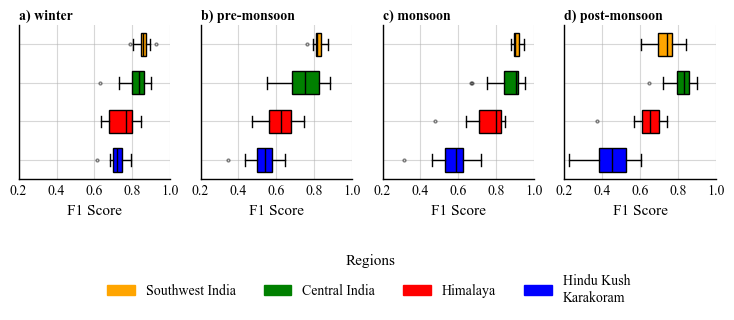

In [6]:
names = ['HKK', 'him', 'central_india','southwest_india']
colors = ['b', 'r' ,'g' ,'orange']

fig, ax = plt.subplots(1,4, figsize=(9, 2), sharex=True, sharey=False, dpi=100)

for idx, season in enumerate(['a) winter', 'b) pre-monsoon', 'c) monsoon', 'd) post-monsoon']):
    all_data = []
    for name, col, pos in zip(names, colors, [0,1,2,3]):
        all_models = load_and_clip(name)
        data = all_models.sel(cluster=idx).mean(['lat','lon'])
        data = 2 * (data.precision * data.recall) / (data.precision + data.recall)
        all_data.append(data.values)
        ax[idx].boxplot(
            data.values.flatten(),
            positions=[pos],                    
            vert=False,
            patch_artist=True,
            widths=0.6,
            boxprops=dict(facecolor=col, color='black', lw=1, edgecolor='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', color='black', markersize=2, alpha=0.5),
        )
        print('Average F1 score for', name, 'in', season, ':', data.values.mean(), '+', data.values.std())

    all_data = np.array(all_data)
    models = all_models.model.values.tolist()

    ax[idx].set_yticks(np.arange(0,4,1))
    ax[idx].text(0.0, 1.1, season, transform=ax[idx].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

legend_patches = [
    mpatches.Patch(color='orange',  label='Southwest India'),
    mpatches.Patch(color='g',  label='Central India'),
    mpatches.Patch(color='r',  label='Himalaya'),
    mpatches.Patch(color='b',  label='Hindu Kush \nKarakoram')
]

for a_x in ax.flatten():
    a_x.set_xlim(0.2,1)
    a_x.spines['top'].set_visible(False)
    a_x.spines['right'].set_visible(False)
    a_x.grid(True, alpha=0.5)
    a_x.set_xticks(np.arange(0.2, 1.1, 0.2))
    a_x.set_xticklabels(np.arange(0.2, 1.1, 0.2).round(1), fontsize=10)
    a_x.tick_params(axis='both', which='both', length=0)
    a_x.set_yticklabels([])

for i in range(4):
    ax[i].set_xlabel('F1 Score')

ax[1].legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(-.7, -0.4), fontsize=10, ncol=4, frameon=False, title='Regions')

# Save figure
f1_path = FIGURES_DIR / 'f1_scores.png'
fig.savefig(f1_path, dpi=300, bbox_inches='tight', transparent=True)
print(f"Saved figure: {f1_path}")

In [7]:
four_seas_reference_all_vars = CLUSTERING_PATH /'four_seas_all_vars_clust.nc'

# Create the labels for the training
lables_param = {
'n_seas': 4
}

four_seas_reference = xr.open_dataset(four_seas_reference_all_vars).breakpoints

mask = four_seas_reference.isel(cluster=0).isnull()
four_seas_reference = X_labels(four_seas_reference, **lables_param)
four_seas_reference = four_seas_reference.where(~mask, drop=True)

four_seas_reference = four_seas_reference.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
four_seas_reference.rio.write_crs("epsg:4326", inplace=True);

In [8]:
ref_dates = pd.date_range("2023-01-01", "2023-12-31", freq="D")
day_to_month = xr.DataArray(ref_dates.month, coords={"dayofyear": ref_dates.dayofyear}, dims="dayofyear")

In [9]:
def load_and_clip(name):

    nnull = 0
    bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

    if name == 'southwest_india':
        nnull = [18, 22]
    elif name == 'HKK':
        nnull = [35, 35]
    elif name == 'him':
        nnull = [105, 105]
    elif name == 'central_india':
        nnull = [90, 83]

    all_models = []
    for model in s.CMIP6_models:
        if os.path.exists(os.path.join(s.perceptron_path, 'historical_prediction', f'historical_pred_{s.name}_{model}.nc')):
            dataset_eval = xr.open_dataset(os.path.join(s.perceptron_path, 'historical_prediction', f'historical_pred_{s.name}_{model}.nc'))
            all_models.append(dataset_eval)

    all_models = xr.concat(all_models, dim='model',coords='minimal', compat='override')
    all_models = all_models.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    all_models.rio.write_crs("epsg:4326", inplace=True);
    all_models = all_models.rio.clip(bnd.geometry.apply(mapping))
    
    return all_models, bnd, nnull

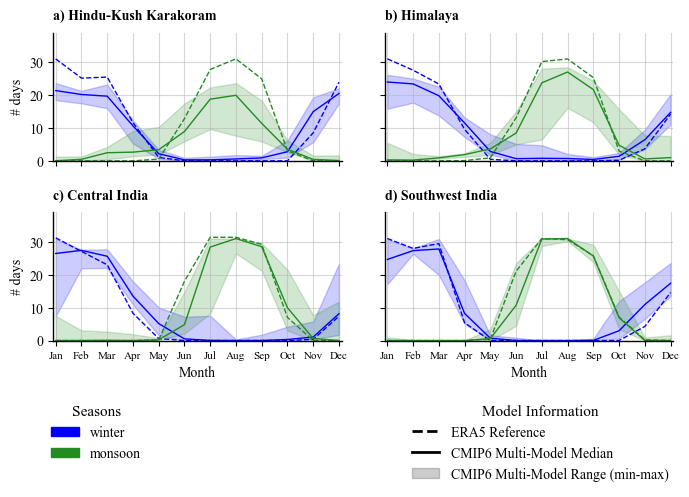

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

season = 0
x_pos = 0.0

fig, ax = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.15)  # più spazio verticale

for idx, box, a_x in zip(range(len(names)), names, ax.flatten()):
    
    data, bnd, nnull = load_and_clip(box)

    for st, col in zip([0, 2],  ['blue', 'forestgreen']):

        # Reference (ERA5)
        cycle_reference = four_seas_reference.rio.clip(bnd.geometry.apply(mapping), bnd.crs, drop=True)
        cycle_reference = cycle_reference.where(cycle_reference == st).groupby(day_to_month).count(dim='dayofyear')
        cycle_reference = cycle_reference.sum(dim=['lat', 'lon'], skipna=True) / nnull[1]

        # Projection (CMIP6)
        cycle = data.where(data == st).resample(time='1ME').count()
        cycle = cycle.groupby('time.month').mean(dim='time', skipna=True).sum(dim=['lat', 'lon'], skipna=True) / nnull[0]

        # Plot median + range
        cycle.predictions.median('model').plot(ax=a_x, color=col, linewidth=1, add_legend=False)
        a_x.fill_between(cycle.month, cycle.predictions.min('model'), cycle.predictions.max('model'), color=col, alpha=0.2)

        # Reference line
        cycle_reference.plot(ax=a_x, color=col, linewidth=1, linestyle='--', add_legend=False)

    # Stile grafico
    a_x.spines['top'].set_visible(False)
    a_x.spines['right'].set_visible(False)
    a_x.grid(True, alpha=0.5)
    a_x.set_ylim(0, 39)
    a_x.set_xlim(0.9, 12.1)
    a_x.set_xticks(np.arange(1, 13))
    a_x.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=8)
    
    a_x.set_title('')
    a_x.set_xlabel('')
    a_x.set_ylabel('', fontsize=10)

# Etichette globali
ax[0][0].set_ylabel('# days', fontsize=10)
ax[1][0].set_ylabel('# days', fontsize=10)
ax[1][0].set_xlabel('Month', fontsize=10)
ax[1][1].set_xlabel('Month', fontsize=10)

# Legenda tecnica (riga inferiore sinistra)
ax[1][0].plot([], [], color='k', lw=2, ls='--', label='ERA5 Reference')
ax[1][0].plot([], [], color='k', lw=2, label='CMIP6 Multi-Model Median')
ax[1][0].fill_between([], [], [], color='k', alpha=0.2, label='CMIP6 Multi-Model Range (min-max)')
ax[1][0].legend(loc='upper left', bbox_to_anchor=(1.2, -0.4), fontsize=10, frameon=False, title='Model Information')

# Legenda stagioni (riga inferiore destra)
legend_patches = [
    mpatches.Patch(color='blue', label='winter'),
    mpatches.Patch(color='forestgreen', label='monsoon')
]
ax[1][1].legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(-1.2, -0.4), fontsize=10, frameon=False, title='Seasons')

# Titoli subplot
ax[0][0].text(x_pos, 1.1, 'a) Hindu-Kush Karakoram', transform=ax[0][0].transAxes, fontsize=10, fontweight='bold', ha='left')
ax[0][1].text(x_pos, 1.1, 'b) Himalaya', transform=ax[0][1].transAxes, fontsize=10, fontweight='bold', ha='left')
ax[1][0].text(x_pos, 1.1, 'c) Central India', transform=ax[1][0].transAxes, fontsize=10, fontweight='bold', ha='left')
ax[1][1].text(x_pos, 1.1, 'd) Southwest India', transform=ax[1][1].transAxes, fontsize=10, fontweight='bold', ha='left')

# Salvataggio opzionale
shape_path = FIGURES_DIR / 'seasonal_shapes.png'
fig.savefig(shape_path, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

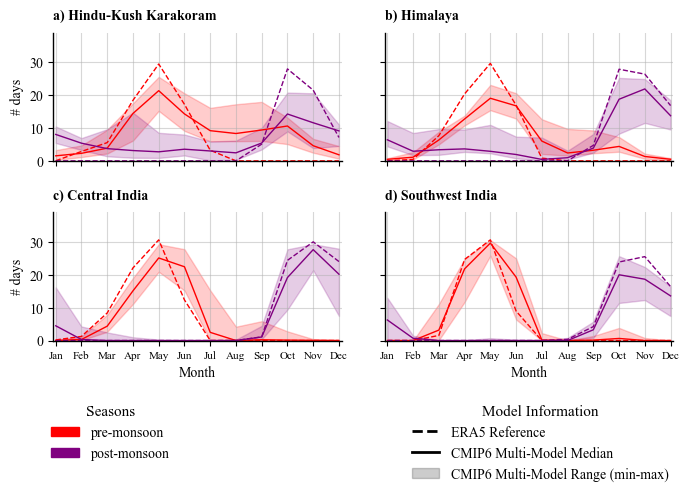

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

season = 0
x_pos = 0.0  # subplot title position

fig, ax = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.15)

for idx, box, a_x in zip(range(len(names)), names, ax.flatten()):
    data, bnd, nnull = load_and_clip(box)
    for st, col in zip([1, 3], ['red', 'purple']):
        cycle_reference = four_seas_reference.rio.clip(bnd.geometry.apply(mapping), bnd.crs, drop=True)
        cycle_reference = cycle_reference.where(cycle_reference == st).groupby(day_to_month).count(dim='dayofyear')
        cycle_reference = cycle_reference.sum(dim=['lat', 'lon'], skipna=True) / nnull[1]
        cycle = data.where(data == st).resample(time='1ME').count()
        cycle = cycle.groupby('time.month').mean(dim='time', skipna=True).sum(dim=['lat', 'lon'], skipna=True) / nnull[0]
        cycle.predictions.median('model').plot(ax=a_x, color=col, linewidth=1, add_legend=False)
        a_x.fill_between(cycle.month, cycle.predictions.min('model'), cycle.predictions.max('model'), color=col, alpha=0.2)
        cycle_reference.plot(ax=a_x, color=col, linewidth=1, linestyle='--', add_legend=False)
    a_x.spines['top'].set_visible(False)
    a_x.spines['right'].set_visible(False)
    a_x.grid(True, alpha=0.5)
    a_x.set_ylim(0, 39)
    a_x.set_xlim(0.9, 12.1)
    a_x.set_xticks(np.arange(1, 13))
    a_x.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
    a_x.set_title('')
    a_x.set_xlabel('')
    a_x.set_ylabel('', fontsize=10)

ax[0][0].set_ylabel('# days', fontsize=10)
ax[1][0].set_ylabel('# days', fontsize=10)
ax[1][0].set_xlabel('Month', fontsize=10)
ax[1][1].set_xlabel('Month', fontsize=10)

ax[1][0].plot([], [], color='k', lw=2, ls='--', label='ERA5 Reference')
ax[1][0].plot([], [], color='k', lw=2, label='CMIP6 Multi-Model Median')
ax[1][0].fill_between([], [], [], color='k', alpha=0.2, label='CMIP6 Multi-Model Range (min-max)')
ax[1][0].legend(loc='upper left', bbox_to_anchor=(1.2, -0.4), fontsize=10, frameon=False, title='Model Information')

legend_patches = [
    mpatches.Patch(color='red', label='pre-monsoon'),
    mpatches.Patch(color='purple', label='post-monsoon')
]
ax[1][1].legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(-1.2, -0.4), fontsize=10, frameon=False, title='Seasons')

ax[0][0].text(x_pos, 1.1, 'a) Hindu-Kush Karakoram', transform=ax[0][0].transAxes, fontsize=10, fontweight='bold', ha='left')
ax[0][1].text(x_pos, 1.1, 'b) Himalaya', transform=ax[0][1].transAxes, fontsize=10, fontweight='bold', ha='left')
ax[1][0].text(x_pos, 1.1, 'c) Central India', transform=ax[1][0].transAxes, fontsize=10, fontweight='bold', ha='left')
ax[1][1].text(x_pos, 1.1, 'd) Southwest India', transform=ax[1][1].transAxes, fontsize=10, fontweight='bold', ha='left')

supp_path = SUPP_FIGURES_DIR / 'seasonal_shapes_supplementary.png'
fig.savefig(supp_path, dpi=300, bbox_inches='tight', transparent=True)
plt.show()